# **Module 4: Introduction to Neural Networks and Deep Learning**

### **Prepared by: Dr. Hum Nath Bhandari, Department of Mathematics, RWU**

### **Course**: MATH 355/COMSC 415-Machine Learning

###  **Case Study2** :  **Predicting Strength of High-Performance Concrete Using Deep Neural Networks**

### Name:




## **Overview**

In this case study, we build simple feedforward neural networks models and we perform various model selection strategies to identify the best model. We have learned various theoretical aspects of  neural networks, activation functions, optimization, backpropagation, and multilayer neural networks. Now, this is the time to implement our skills in case study on testing the quality of concrete using multilayer deep neural networks, called DNN.  

**Problem Background**:

- Concrete is the most important material in several civil engineering and construction projects.

- Its compressive strength is a highly nonlinear function of quality and age of various ingredients. These ingredients include cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, and fine aggregate.

- Underlying data is collected  by carrying out the testing of concrete on either a concrete cube or cylinder through the use of a compression testing machine (2,000 kilonewtons) to calculate **compressive strength**  of the concret.

- The test is extensive and takes a long time, so the possibility of predicting the compressive strength provies a significant importance in these kinds of industries.

- **Research Question: In this case study, we want to create a model that allows us to predict the compressive strength of concrete based on the ingredients used in the mixture**.

- Related Paper: https://www.sciencedirect.com/science/article/abs/pii/S0008884698001653?via%3Dihub


## **Data**

- One version of the dataset is availabe on Bridges.

- Original data is also available at the UCI Machine Learning Repository at the following link:

    Data Source: https://archive.ics.uci.edu/ml/datasets/concrete+compressive+strength

- To predict the compressive strength of concrete from the ingredients of the mixture, we can use the concrete compressive strength dataset containing eight quantitative input variables and one quantitative output variable.


- The following shows all of the variables, followed by a brief description:
    
   - **Cement** -- quantitative -- kg in a m3 mixture

   - **Blast Furnace Slag** -- quantitative -- kg in a m3 mixture

   - **Fly Ash** -- quantitative -- kg in a m3 mixture

   - **Water** -- quantitative -- kg in a m3 mixture

   - **Superplasticizer** -- quantitative -- kg in a m3

   - **Coarse Aggregate** -- quantitative -- kg in a m3 mixture

   - **Fine Aggregate** -- quantitative -- kg in a m3 mixture

   - **Age** -- quantitative -- Day (1~365)

   - **Concrete compressive strength** -- quantitative -- MPa,  megapascals

### **Step 1(Working with Google Colab): Mount your Google Drive and Setup paths for Data and Results**

#### **Mount Google Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google'

#### **Data and Results Paths**



In [ ]:
data_path = "/content/drive/MyDrive/Machine_Learning/Regression_Models/Data/" # make similar to this path

output_dir_path = "/content/drive/MyDrive/Machine_Learning/Regression_Models/Results/" #make similar to this path

#### **Suppress Unnessary warnings**

In [ ]:

import warnings
warnings.filterwarnings('ignore')

### **Step 2:  Loading, Cleaning and Exploring Data**

 - Load  **Concrete_Data.xls** data in colab
 - Display basic information about the data.
 - Handle missing values (if any).
 - Create some visualizations.
 - See relationships among variables.
 - Create correlations in heatmaps.

In [ ]:
import pandas as pd

column_names  = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea','furnishingstatus']

#data = pd.read_excel(data_path + 'Concrete_Data.xls')

data = pd.read_csv(data_path + 'Housing.csv')
#data = pd.read_excel(data_path + 'Concrete_Data.xlsx', names= column_names)

numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(data.head())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:

print(data.info())
print(data.describe())
print(data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

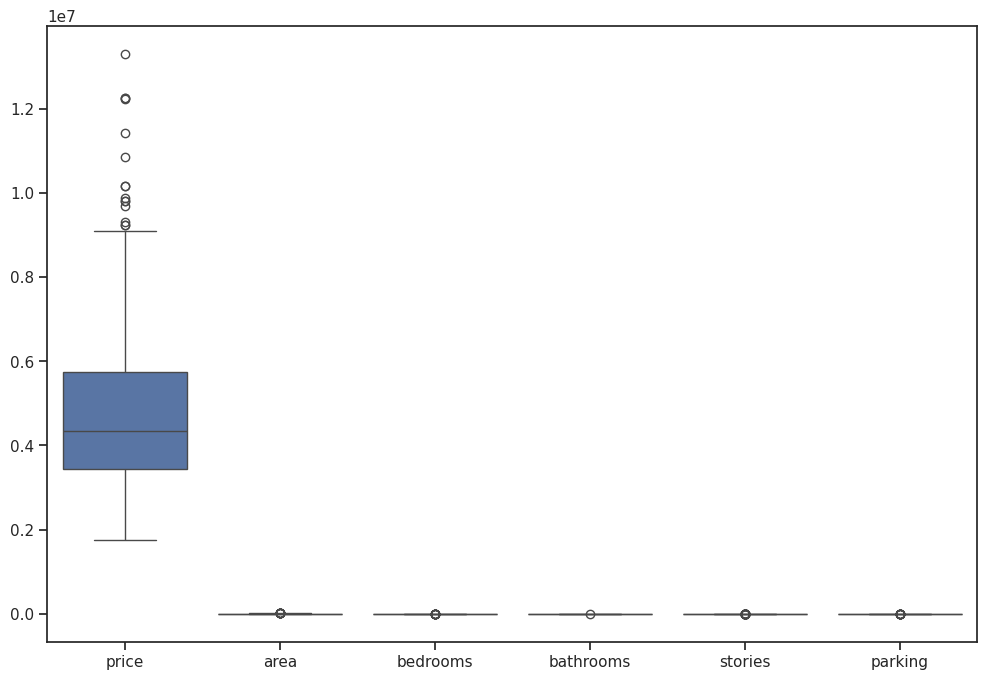

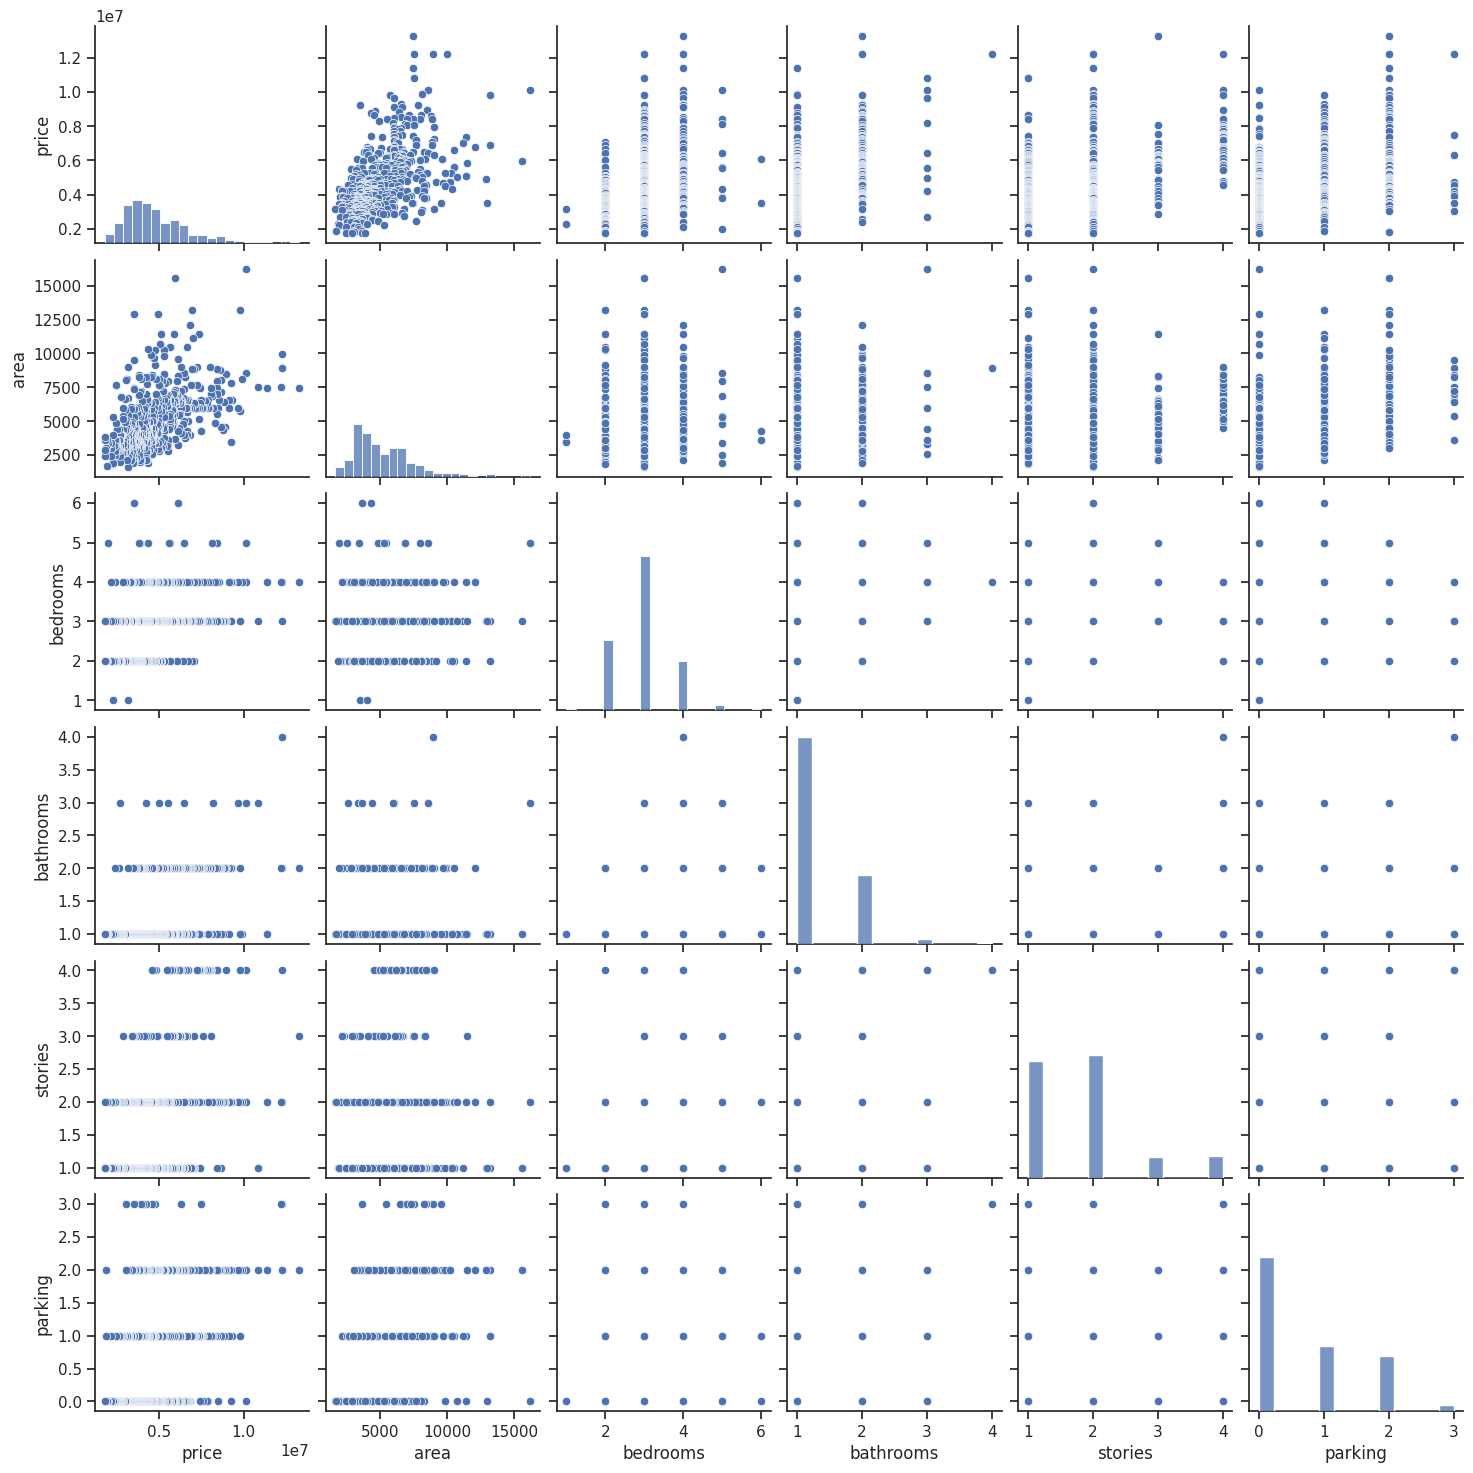

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns

fig = plt.figure(figsize= (12,8))

sns.set(style="ticks")

sns.boxplot(data = data[numeric_cols])

fig.savefig(output_dir_path +"data_boxplots.pdf", dpi = 600)

plt.show()

g = sns.pairplot(data = data[numeric_cols].dropna())
g.fig.savefig(output_dir_path+"data_pair_plots.pdf", dpi = 600)
plt.show()


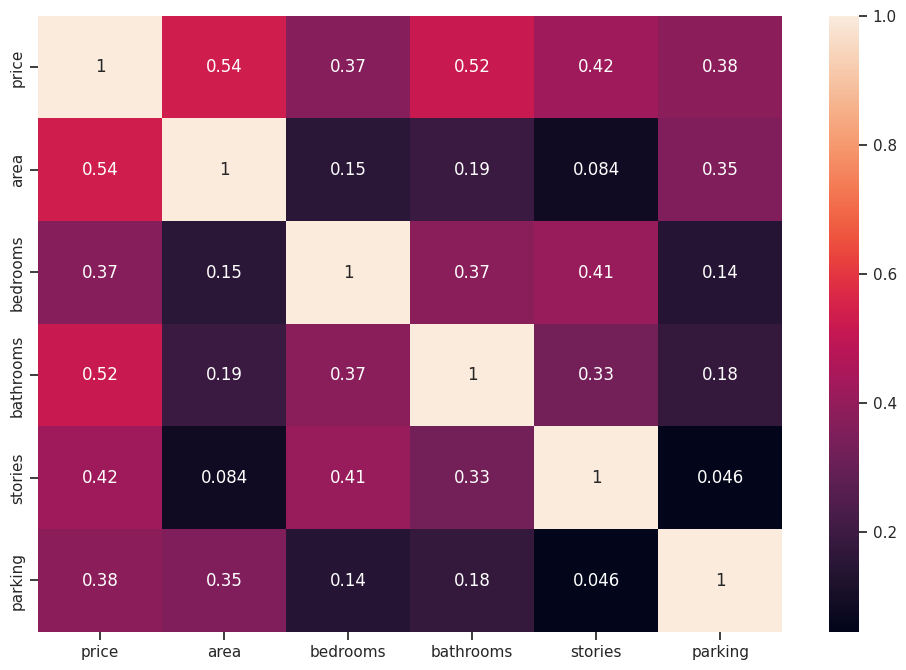

In [ ]:
fig = plt.figure(figsize = (12,8))

sns.heatmap(data[numeric_cols].corr(), annot = True)

fig.savefig(output_dir_path+"heatmap.pdf", dpi = 600)

plt.show()



## **Step 3: Data Transformantion and Input Preparation**

 - Transform your data set if necessary.
 - Explore the transformed data.
 - Identify input features(X_data) and target variable (y_data).
 - Create training and test sets.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data[numeric_cols])


data_scaled =  pd.DataFrame(data_scaled, columns = numeric_cols, index=data.index)
data_scaled.head()


,price,area,bedrooms,bathrooms,stories,parking
0,1.000000,0.396564,0.6,0.333333,0.666667,0.666667
1,0.909091,0.502405,0.6,1.000000,1.000000,1.000000
2,0.909091,0.571134,0.4,0.333333,0.333333,0.666667
3,0.906061,0.402062,0.6,0.333333,0.333333,1.000000
4,0.836364,0.396564,0.6,0.000000,0.333333,0.666667


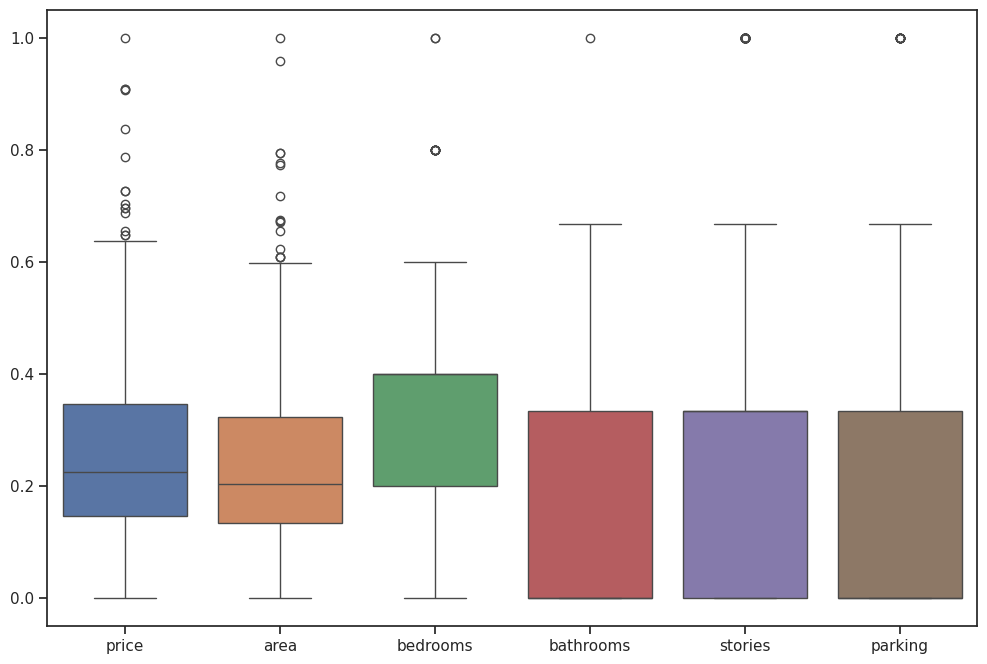

In [ ]:
fig = plt.figure(figsize= (12,8))

sns.set(style="ticks")


sns.boxplot(data = data_scaled)

fig.savefig(output_dir_path +"data_scaled_boxplots.pdf", dpi = 600)
plt.show()


In [ ]:
input_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


X_data = data_scaled[input_features]

y_data = data_scaled['price']

print("Shape of X_data", X_data.shape)
print("Shape of y_data", y_data.shape)


Shape of X_data (545, 5)
Shape of y_data (545,)


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.30, random_state = 20)

print("Training Sets:",  X_train.shape, y_train.shape)
print("Test Sets: ", X_test.shape, y_test.shape)


Training Sets: (381, 5) (381,)
Test Sets:  (164, 5) (164,)


## **Step 4: Building and Implementing Neural Networks Models**

 - Build a simple Deep Neural Network(DNN) model.
 - Display the model summary and understand how many parameters to be optimized(learned).
 - Fit the constructed model.
 - Find the predictions in test data.
 - Calculate the prediction accuracy.






### **Build DNN Model**

In [ ]:

#Step 1: Import necessary libraries =======

from keras.models import Sequential

from keras.layers import Dense

#Step 2: Initialize Neural Network Model Configuration

#Create sequential model object
model = Sequential()

#Add first hidden layer with some neurons. Specifiy input dimension and activation function.
model.add(Dense(20, input_dim = 5, activation='relu'))

#Add second hidden layer with some neurons
model.add(Dense(10, activation='relu'))

#Add third  hidden layer with some neurons
model.add(Dense(10, activation='relu'))

#Add output layer with 1 neuron. choose activation function depending on problem.
model.add(Dense(1, activation='linear'))

#Compile the model with selected optimizer and loss function
model.compile(optimizer='adam', loss='mean_squared_error')

print(model.summary())



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 451 (1.76 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

None


### **Fit DNN Model**

In [ ]:
model_output = model.fit(X_train, y_train, epochs= 50, batch_size = 32,  validation_split = 0.2, verbose=1 )


Epoch 1/50


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0484 - val_loss: 0.0335
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0236 - val_loss: 0.0187
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0140 - val_loss: 0.0210
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0128 - val_loss: 0.0181
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0114 - val_loss: 0.0176
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0113 - val_loss: 0.0174
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - val_loss: 0.0174
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0099 - val_loss: 0.0172
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0090 - val_loss: 0.0170
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0115 - val_loss: 0.0168
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0111 - val_loss: 0.0169
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0087 - val_loss: 0.0167

### **Visualize Training History**

In [ ]:
model_output.history['loss']


[0.04593661427497864,
 0.018394900485873222,
 0.013855613768100739,
 0.012671797536313534,
 0.011239494197070599,
 0.011011469177901745,
 0.010638984851539135,
 0.010455349460244179,
 0.010207719169557095,
 0.010056077502667904,
 0.009892093949019909,
 0.009789147414267063,
 0.009670514613389969,
 0.009620429016649723,
 0.009446109645068645,
 0.009408382698893547,
 0.009338387288153172,
 0.009304085746407509,
 0.009216890670359135,
 0.009278703480958939,
 0.009155601263046265,
 0.009184455499053001,
 0.00928428117185831,
 0.009085875004529953,
 0.00908518023788929,
 0.009002652019262314,
 0.009009450674057007,
 0.008955562487244606,
 0.008867502212524414,
 0.008857855573296547,
 0.008894773200154305,
 0.008824723772704601,
 0.008785326965153217,
 0.00889491941779852,
 0.008817221969366074,
 0.008685759268701077,
 0.008786819875240326,
 0.008703724481165409,
 0.008657978847622871,
 0.008636358194053173,
 0.00865307915955782,
 0.008570436388254166,
 0.008562174625694752,
 0.0085305459797

In [ ]:
model_output.history['val_loss']

[0.033465489745140076,
 0.01867024041712284,
 0.021031582728028297,
 0.01807231269776821,
 0.017646722495555878,
 0.01739504560828209,
 0.01736714132130146,
 0.01721777208149433,
 0.01696045510470867,
 0.01682189293205738,
 0.016862967982888222,
 0.016688700765371323,
 0.01650473289191723,
 0.01660468615591526,
 0.016309458762407303,
 0.016305990517139435,
 0.016199227422475815,
 0.016112888231873512,
 0.016188129782676697,
 0.01607383042573929,
 0.01626564934849739,
 0.016061723232269287,
 0.016251925379037857,
 0.01590001955628395,
 0.01600099913775921,
 0.015872161835432053,
 0.01572887971997261,
 0.01577002927660942,
 0.015866896137595177,
 0.015772094950079918,
 0.015671584755182266,
 0.01573159731924534,
 0.015576322562992573,
 0.015409687533974648,
 0.01576387509703636,
 0.015490754507482052,
 0.015385734848678112,
 0.015648871660232544,
 0.01546437107026577,
 0.015503332018852234,
 0.015453902073204517,
 0.015364405699074268,
 0.015273669734597206,
 0.015437070280313492,
 0.015

In [ ]:

def loss_plot(model_output):

  fig = plt.figure(figsize = (8,4))

  plt.plot(model_output.epoch, model_output.history['loss'], '--o', color = 'darkblue')

  plt.plot(model_output.epoch, model_output.history['val_loss'], '--o', color = 'olive')

  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss(MSE)")
  plt.legend(['Training loss', "Validation loss"],  loc= 'upper right')
  sns.set_style("whitegrid")
  fig.savefig(output_dir_path+ "train_valiation_loss_plot.png",dpi=600)

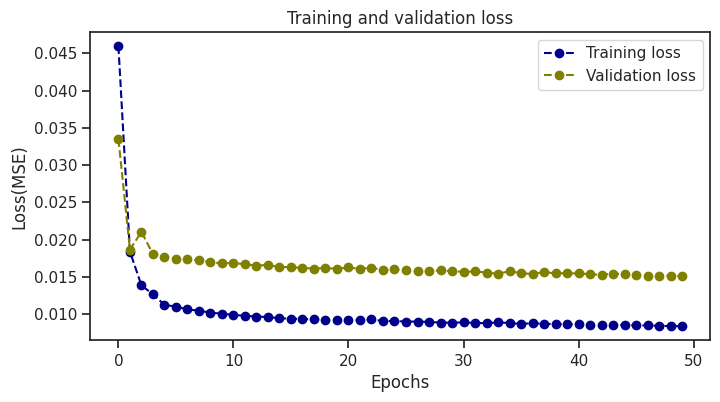

In [ ]:
loss_plot(model_output)

### **Make Predictions in Test Data**

In [ ]:

y_pred = model.predict(X_test)
#y_pred
y_pred = y_pred.ravel()
print(y_pred)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[0.4025239  0.30044156 0.4273634  0.14487468 0.48454472 0.15955703
 0.3770995  0.2043048  0.17006372 0.39145815 0.34234375 0.36326683
 0.542914   0.18089266 0.38530642 0.40157107 0.3138728  0.12922956
 0.19283216 0.2680795  0.26069278 0.3359494  0.13349298 0.21198016
 0.12966517 0.23814347 0.1894294  0.12385875 0.14552571 0.1144819
 0.13954632 0.202288   0.27881464 0.29391226 0.20035084 0.13653412
 0.22763261 0.5191711  0.42128322 0.20333679 0.25347134 0.24376906
 0.11781015 0.2516766  0.28655404 0.26069278 0.42965734 0.13610739
 0.21813671 0.44586673 0.15601014 0.12010641 0.3365819  0.20760423
 0.29256696 0.4285048  0.13869609 0.0941608  0.23376174 0.3029746
 0.11844774 0.1293442  0.52624965 0.47039798 0.2151187  0.15601014
 0.26673862 0.42453828 0.1262166  0.44586673 0.17876776 0.29915687
 0.46781287 0.1948731  0.17820357 0.45736948 0.1671574  0.17986779
 0.5229186  0.18105374 0.12523487 0.5758209  0.20940216 0.3267683
 0.25628626 0.22949845 0.33

## Calculate Evaluation Scores

In [ ]:

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import math

import numpy as np

def calculate_scores(y_true, y_pred):
    #=====mse====
    mse = mean_squared_error(y_true, y_pred)
    #===== rmse===
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    #===== R2===
    R2_score = r2_score(y_true, y_pred)
    #===== R===
    R = np.corrcoef(y_true, y_pred)
    #===== mape===
    mape = mean_absolute_percentage_error(y_true, y_pred)

    output = {'rmse':rmse, 'R2_score': R2_score, 'R':R[0,1], 'mape': mape}
    return output


In [ ]:

test_scores = calculate_scores(y_test, y_pred)
print(test_scores) # mape value can be unreasonably high


{'rmse': 0.11170942944586207, 'R2_score': 0.5745593281361877, 'R': np.float64(0.7608293035374742), 'mape': 3542473967166.9985}


## **Step 5: Improving  Model Performance**

 - Remove the outliers from data.

 - Create comparative boxplots of the data with and without outliers.

 - Build and test the  model in a new data set after removing outliers.

 - Fit the model, find prediction, and accuracy scores. Compare with the previous model.

 - Visualize true vs predicted graphs of two constructed models.



In [ ]:

Q1 = data_scaled.quantile(0.25)

Q3 = data_scaled.quantile(0.75)


IQR = Q3 - Q1

print(IQR)

data_scaled_new = data_scaled[ ~((data_scaled < (Q1 - 1.5 * IQR)) | (data_scaled > (Q3 + 1.5 * IQR))).any(axis=1)]

print(data_scaled_new.shape)


price        0.200000
area         0.189691
bedrooms     0.200000
bathrooms    0.333333
stories      0.333333
parking      0.333333
dtype: float64
(460, 6)


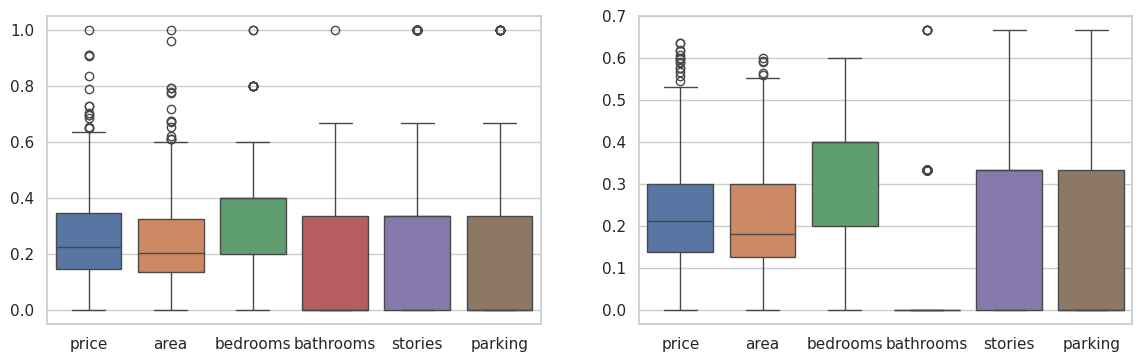

In [ ]:

fig = plt.figure(figsize= (14,4))
plt.subplot(121)
sns.boxplot(data = data_scaled)

plt.subplot(122)
sns.boxplot(data = data_scaled_new)
fig.savefig(output_dir_path +"comparative_boxplots_with_and_without_outliers.pdf", dpi = 600)
plt.show()


In [ ]:
input_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

X_data_new = data_scaled_new[input_features]

y_data_new = data_scaled_new['price']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_data_new, y_data_new, test_size = 0.30, random_state=20)




In [ ]:

model2 = Sequential()

model2.add(Dense(20, input_dim = 5, activation='relu'))

model2.add(Dense(10, activation='relu'))

model2.add(Dense(10, activation='relu'))
model2.add(Dense(1, activation='linear'))
model2.compile(optimizer='adam',loss='mean_squared_error')

print(model.summary())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 20)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,355 (5.30 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 904 (3.54 KB)

None


In [ ]:
model_output2  = model2.fit(X_train_new, y_train_new, epochs= 100, batch_size = 32, validation_split = 0.2, verbose=1)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0822 - val_loss: 0.0470
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0422 - val_loss: 0.0256
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181 - val_loss: 0.0163
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0128 - val_loss: 0.0139
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0101 - val_loss: 0.0137
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - val_loss: 0.0136
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0113 - val_loss: 0.0137
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0108 - val_loss: 0.0140
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0101 - val_loss: 0.0139
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106 - val_loss: 0.0136
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0121 - val_loss: 0.0132
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - val_loss: 0.0132


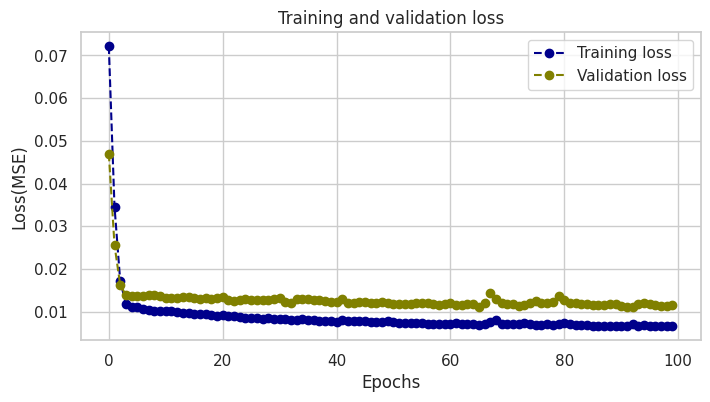

In [ ]:
loss_plot(model_output2)

In [ ]:

y_pred_new = model2.predict(X_test_new)
y_pred_new = y_pred_new.ravel()
print(y_pred_new)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[0.31994262 0.20745143 0.34568977 0.09284898 0.21392526 0.13666789
 0.10336745 0.17831366 0.3273126  0.2919604  0.23233448 0.38377336
 0.20814729 0.25964352 0.20471048 0.21753179 0.16910118 0.14047718
 0.27678615 0.18007345 0.10435267 0.25211877 0.15219133 0.27295384
 0.4630765  0.22439502 0.19314092 0.21932898 0.17622344 0.17077173
 0.210871   0.12392707 0.24101406 0.19046028 0.2997066  0.27272868
 0.15568747 0.15097228 0.15104847 0.28977007 0.16790083 0.3391219
 0.32746848 0.18413706 0.23515178 0.30320373 0.3077873  0.30493385
 0.24297363 0.19399886 0.2206052  0.21476641 0.39433467 0.1734946
 0.22831522 0.24513507 0.20576425 0.34179348 0.22805414 0.30752516
 0.29637414 0.30822778 0.21342565 0.39887872 0.22287284 0.30415934
 0.31019792 0.27639937 0.32417202 0.39402968 0.16569208 0.31963482
 0.21935561 0.11272402 0.18437131 0.21392526 0.21765454 0.30661458
 0.18334164 0.18893282 0.3196658  0.3269445  0.1818064  0.22103304
 0.10009655 0.12086664 0.1

In [ ]:

test_scores_new = calculate_scores(y_test_new, y_pred_new)
print(test_scores_new)


{'rmse': 0.10464374516559669, 'R2_score': 0.4467316291859238, 'R': np.float64(0.6849084096806913), 'mape': 11665980248955.736}


## **True vs Predicted Graph**

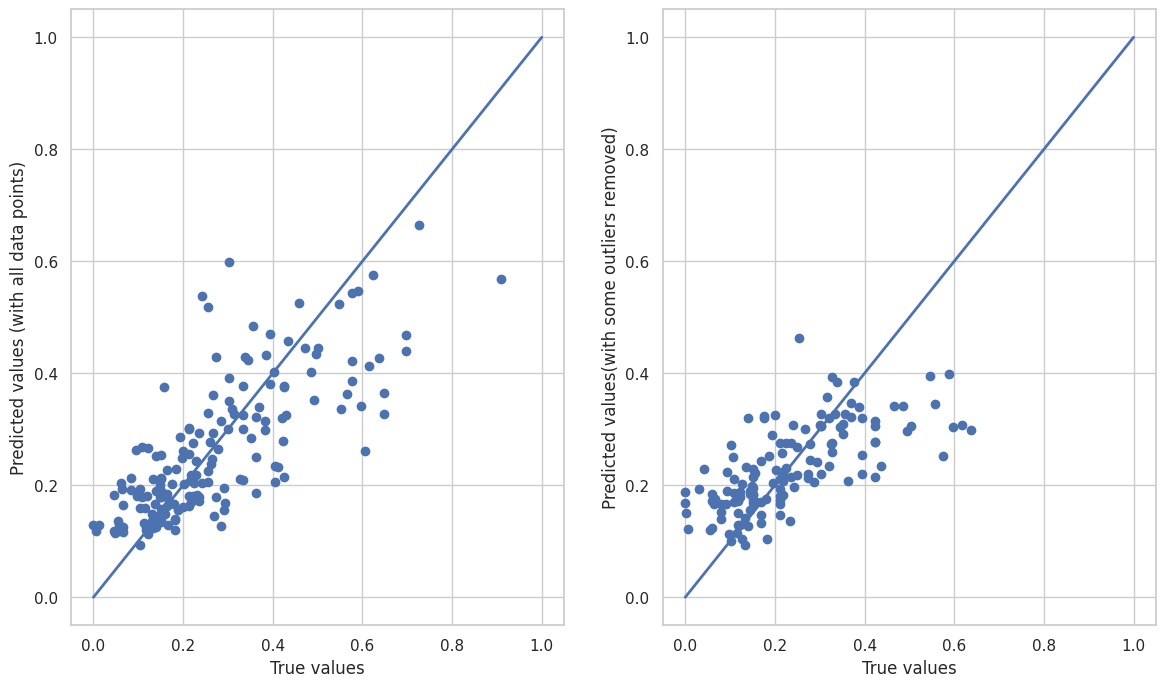

In [ ]:

fig = plt.figure(figsize= (14,8))
plt.subplot(121)
plt.scatter(y_test,y_pred)
plt.plot([0, 1], [0, 1], linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted values (with all data points)")

plt.subplot(122)
plt.scatter(y_test_new, y_pred_new)
plt.plot([0, 1], [0, 1], linewidth=2)
plt.xlabel("True values")
plt.ylabel("Predicted values(with some outliers removed)")
fig.savefig(output_dir_path +"comparative_true_vs_predicted_values_plots.pdf", dpi = 600)


## **Step 6: More Advanced  Tasks**

- Write a function to visualize training error vs epochs.

- Write a function which can build more generic DNN models.

- Write a function which can be used for hyperparameter tuning of the models.

- Write a function which helps to train the model in a full scale with optimized hyperparameters.

- Write a function which performs results visualization.

- Write a function which perform statistical analysis.


## Advanced Tasks: Building and Implementing DNN Regressor with Varying Degree of Complexities

We will be writing the following functionalities.

1. **DNN_Regressor()**: Write a function which can build generic DNN model for Regression.

2. **Loss_Plot():** Write a function to visualize training error vs epochs.

3. **DNN_Hyperparameter_Tuning()**: Write a function which can be used for hyperparameter tuning of the models.

4. **DNN_Regressor_Implementation()**: Write a function which helps to train the model in a full scale with optimized hyperparameters.

5. **Multiple_DNN_Regressors()**: Write a function which helps to implement multiple DNN Regressors

6. **Results_Visualization()**: Write a function which performs results visualization.

7. **Statistical_Analysis()**:Write a function which perform statistical analysis.

## Build DNN Regressor¶

In [ ]:

import tensorflow as tf
from keras import  Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import optimizers
import time
import math


In [ ]:
def write_dic_to_file(dic_name, file_name):
  file = open(file_name, 'w')
  file.write(str(dic_name))
  file.close()

import ast
def read_dic_from_file(file_name):
  file = open(file_name, "r")
  contents = file.read()
  dictionary = ast.literal_eval(contents)
  file.close()
  return dictionary


In [ ]:

def DNN_Regressor(layers, input_features, output_dim, optimizer = 'Adam', learning_rate = 0.001, verbose = 1):

  #Initialize sequential modeling architecture
  model = Sequential()

  #Add hidden layers and neurons
  for i in range(len(layers)):
    if len(layers)==1:
      model.add(Dense(layers[i], input_dim = input_features,  activation='relu'))
      model.add(Dropout(0.10))
    else:
        if i == 0:
          model.add(Dense(layers[i], input_dim = input_features,  activation='relu'))
        else:
          model.add(Dense(layers[i], activation='relu'))

        model.add(Dropout(0.10))

  #Add output layers
  model.add(Dense(output_dim, activation = 'linear')) # Neurons = 1, because we have just one continuous target to predict

  #Select optimizers and learning rates
  if optimizer == 'Adam':
    opt = optimizers.Adam(learning_rate = learning_rate)
  elif optimizer == 'Adagrad':
    opt = optimizers.Adagrad(learning_rate = learning_rate)
  elif optimizer == 'Nadam':
    opt = optimizers.Nadam(learning_rate = learning_rate)
  elif optimizer == 'Adadelta':
    opt = optimizers.Adadelta(learning_rate= learning_rate)
  elif optimizer == 'RMSprop':
    opt = optimizers.RMSprop(learning_rate= learning_rate)
  else:
    print("No optimizer found in the list(['Adam', 'Adagrad','Nadam', 'Adadelta', 'RMSprop'])! Please apply your optimizer manually...")

  #model.build(input_shape= (num_features,batch_size))

  #Compile the model
  model.compile(loss='mean_squared_error', optimizer= opt)

  if verbose == 1:
    print(model.summary())
  return model

Testing!

In [ ]:

input_features = 8
output_dim = 1

optimizers_names = ['Adam', 'Adagrad', 'Nadam']

learning_rate = 0.001
verbose = 1
layers = [10, 5, 5]


dnn_model1  = DNN_Regressor(layers, input_features, output_dim, optimizer =  optimizers_names[0], learning_rate= learning_rate, verbose = verbose)
dnn_model1


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

None


<Sequential name=sequential_5, built=True>

## Fit the DNN_Regressor()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1668 - val_loss: 0.1208
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0819 - val_loss: 0.0789
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0564 - val_loss: 0.0549
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0575 - val_loss: 0.0431
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0434 - val_loss: 0.0357
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - val_loss: 0.0313
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0326 - val_loss: 0.0286
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0235 - val_loss: 0.0269
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0240 - val_loss: 0.0257
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0223 - val_loss: 0.0251
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0240 - val_loss: 0.0248
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss

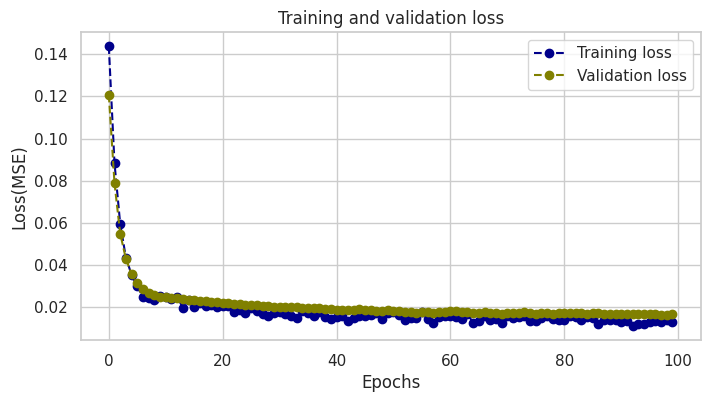

In [ ]:

input_features = 5
output_dim = 1

layers = [10, 5, 5]
optimizers_names = ['Adam', 'Adagrad', 'Nadam']
learning_rate = 0.001
batch_size =  16
epochs =  100
validation_split =  0.2 # 20% of the training data will be used for validation purpose

verbose = 1

dnn_model1  = DNN_Regressor(layers, input_features, output_dim, optimizer =  optimizers_names[0], learning_rate = learning_rate, verbose = verbose)
dnn_model1

model_output1  = dnn_model1.fit(X_train, y_train, epochs= epochs, batch_size = batch_size, validation_split = validation_split, verbose = verbose)
loss_plot(model_output1)


## **Models Construction**

Architectures 1: Single Hidden Layer DNN Models

- Model 1: 10-DNN
- Model 2: 20-DNN
- Model 3: 50-DNN
- Model 4: 100 DNN
- Model 5: 200 DNN


Architectures 2: Multiple Hidden Layers DNN Models
- Model 6: 10-5 DNN
- Model 7: 20-10 DNN
- Model 8: 50-20 DNN
- Model 9: 100-50 DNN
- Model 10: 200-100 DNN

## **Hyperparameter Tuning**

One of the important task for any machine learning project is tuning the hyperparameters of the constructed models. In DNN, important  hyperparameters are the following.

1. Epochs
2. Optimizer
3. Learning rate
4. Bach_size


Epoch can be tuned by using the above loss_plot. We can observe the behavior of training and validation loss to understand the early stoping epoch. The particular epoch will be the best epoch to stop the training and considered as hyperparmeter.


You can combine these hyperparameters in a list:

hyperparameters = [optimizer, epochs, learning rates, batch_sizes]




##  Hyperparameter_Tuning()

In [ ]:

def DNN_Hyperparameter_Tuning(layers, input_features, output_dim, optimizers_names, learning_rates, batch_sizes, epochs, X_train, y_train, X_val, y_val, num_replicates, verbose = 1):

  best_avg_rmse = 99999999999 # start with a big number
  collect_rmse = []
  all_avg_rmse = np.zeros((len(optimizers_names), len(learning_rates), len(batch_sizes)))

  best_hyper_parameters = {"model": layers, "optimizer": None, "learning_rate": None, "batch_size": None,"best_avg_rmse": None}

  #hist_csv_file = 'model_history'+ str(time.time())+'.csv'
  # you can try to record elapsed time.
  for opt in range(len(optimizers_names)):
    for lr in range(len(learning_rates)):
      for batch_size in range(len(batch_sizes)):
        for i in range(num_replicates):
          print("Running for " + optimizers_names[opt] + " optimizer " + str(learning_rates[lr]) +  " learning_rate " +  str(batch_sizes[batch_size]) + " batch_size and " + str(i) +  " replicate " +  "\n")

          model = DNN_Regressor(layers, input_features, output_dim, optimizer =  optimizers_names[opt], learning_rate = learning_rates[lr], verbose = verbose)

          callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience= 5)

          model.fit(X_train, y_train, batch_size = batch_sizes[batch_size], epochs= epochs, validation_data = (X_val, y_val), callbacks=[callback], verbose = 1)

          #==============Making predictions in original scale ==========

          val_pred    =  model.predict(X_val).ravel()

          val_scores = calculate_scores(y_val, val_pred)

          collect_rmse.append(val_scores['rmse'])

        avg_rmse = np.mean(np.array(collect_rmse))
        all_avg_rmse[opt][lr][batch_size] = avg_rmse

        if avg_rmse < best_avg_rmse:
          best_avg_rmse = avg_rmse
          best_hyper_parameters = {"model": layers,  "optimizer": optimizers_names[opt], "learning_rate": learning_rates[lr], "batch_size": batch_sizes[batch_size], "best_avg_rmse": best_avg_rmse}


  output_dictionary = {
        "best_hyper_parameters":  best_hyper_parameters,
        "all_avg_rmse": all_avg_rmse
      }


  #writing output dictionary in the file

  file_name = output_dir_path + "dnn_regressor_" + str(layers) + "hyperparameter_tuning__results" + ".txt"
  write_dic_to_file(output_dictionary, file_name)

  print("Best_hyper_parameters(DNN) \n", output_dictionary['best_hyper_parameters'])

  print("all_avg_rmse: \n", output_dictionary['all_avg_rmse'])

  return (output_dictionary['best_hyper_parameters'])

In [ ]:

X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state = 20)

print("New Training Sets:",  X_train_new.shape, y_train_new.shape)
print("Validation Sets: ", X_val.shape, y_val.shape)


New Training Sets: (304, 5) (304,)
Validation Sets:  (77, 5) (77,)


## **DNN Architecture 1- Single Layer DNN Models**

### Model 1: 10-DNN Hyperparameter Tuning

In [ ]:


output_dir_path = "/content/drive/MyDrive/MATH355-COMSC415-Machine-Learning/Results/" #make similar to this path

model1_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [10],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model1_best_hyperparameters


NameError: name 'DNN_Hyperparameter_Tuning' is not defined

## Model 2: 10-DNN Hyperparameter Tuning

In [ ]:
model2_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [10],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model2_best_hyperparameters

NameError: name 'DNN_Hyperparameter_Tuning' is not defined

## Model 3: 50-DNN Hyperparameter Tuning

In [ ]:
model3_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [50],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model3_best_hyperparameters

## Model 4: 100-DNN Hyperparameter Tuning

In [ ]:
model4_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [100],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model4_best_hyperparameters

## Model 5: 200-DNN Hyperparameter Tuning

In [ ]:
model5_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [200],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model5_best_hyperparameters

## **DNN Architecture 2: Multi-Layers DNN Models**

## Model 6: 10-5-DNN Hyperparameter Tuning

In [ ]:
model6_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [10,5],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model6_best_hyperparameters

## Model 7: 20-10-DNN Hyperparameter Tuning

In [ ]:
model7_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [20,10],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model7_best_hyperparameters

## Model 8: 50-20-DNN Hyperparameter Tuning

In [ ]:
model8_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [50,20],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model8_best_hyperparameters

## Model 9: 100-50-DNN Hyperparameter Tuning

In [ ]:
model9_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [100,50],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model9_best_hyperparameters

## Model 10: 200-100-DNN Hyperparameter Tuning

In [ ]:
mode10_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [200,100],
               input_features = 5,
               output_dim = 1,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train_new,
               y_train = y_train_new,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model10_best_hyperparameters

## **Collecting Best Hyperparameters for Constructed Models**

In [ ]:

models  = [[10], [20],  [50], [100], [200], [10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]


best_hyper_parameters   = [
                            ['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             ['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             ['Adagrad', 0.001, 8], #Model 3: 50-DNN
                            ['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            ['Adagrad', 0.001, 8], #Model 5: 200-DNN
                            ['Adagrad', 0.001, 8], #Model 6: 10-5-DNN
                            ['Adagrad', 0.001, 8], #Model 7: 20-10-DNN
                            ['Adagrad', 0.001, 8], #Model 8: 50-20-DNN
                            ['Adagrad', 0.001, 8], #Model 9: 100-50-DNN
                            ['Adagrad', 0.001, 8], #Model 10: 200-100-DNN
                        ]

                        


"\nmodels  = [[10], [20],  [50], [100], [200], [10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]\n\n\nbest_hyper_parameters   = [\n                            ['Adagrad', 0.001, 8], #Model 1: 10-DNN\n                             ['Adagrad', 0.001, 8], #Model 2: 20-DNN\n                             ['Adagrad', 0.001, 8], #Model 3: 50-DNN\n                            ['Adagrad', 0.001, 8], #Model 4: 100-DNN\n                            ['Adagrad', 0.001, 8], #Model 5: 200-DNN\n                            ['Adagrad', 0.001, 8], #Model 6: 10-5-DNN\n                            ['Adagrad', 0.001, 8], #Model 7: 20-10-DNN\n                            ['Adagrad', 0.001, 8], #Model 8: 50-20-DNN\n                            ['Adagrad', 0.001, 8], #Model 9: 100-50-DNN\n                            ['Adagrad', 0.001, 8], #Model 10: 200-100-DNN\n                        ]\n\n                        "